In [1]:
!pip install pandas scikit-learn numpy matplotlib seaborn tqdm

In [2]:
import pandas as pd
import numpy as np
import json
import re
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/processed_v2.csv")

df = df.rename(columns={
    "processed_text":"text"
})

print("Dataset:", df.shape)
print(df.columns)
df.head()

Dataset: (12759, 2)
Index(['text', 'label'], dtype='object')


,text,label
0,десятки бригад! операція почалась – новий наст...,Fake
1,дуже важкий грип зараз мандрує україною! у діт...,Fake
2,"виcтyп гeнceкa нато nідірвaв мережу: “цiнa, як...",Fake
3,"залишилися лічені дні, почнеться справжня “м'я...",Fake
4,"кремль втретє змінив тактику щодо україни, теп...",Fake


In [5]:
df = df[df["label"].isin(["Real", "Fake"])]
df["text_id"] = range(len(df))
df["label_num"] = df["label"].map({
    "Real":0,
    "Fake":1
})

print("Dataset:", df.shape)
print(df.columns)
df.head()

Dataset: (7860, 4)
Index(['text', 'label', 'text_id', 'label_num'], dtype='object')


,text,label,text_id,label_num
0,десятки бригад! операція почалась – новий наст...,Fake,0,1
1,дуже важкий грип зараз мандрує україною! у діт...,Fake,1,1
2,"виcтyп гeнceкa нато nідірвaв мережу: “цiнa, як...",Fake,2,1
3,"залишилися лічені дні, почнеться справжня “м'я...",Fake,3,1
4,"кремль втретє змінив тактику щодо україни, теп...",Fake,4,1


In [6]:
# STRATIFIED SPLIT

seed = 42

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label_num"],
    random_state=seed
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_num"],
    random_state=seed
)

print(len(train_df), len(val_df), len(test_df))

6288 786 786


In [7]:
# split IDs
train_df["text_id"].to_csv("splits_train_ids.txt", index=False, header=False)
val_df["text_id"].to_csv("splits_val_ids.txt", index=False, header=False)
test_df["text_id"].to_csv("splits_test_ids.txt", index=False, header=False)

In [8]:
# split manifest
manifest = {
    "strategy":"stratified_random",
    "seed":seed,
    "train_size":len(train_df),
    "val_size":len(val_df),
    "test_size":len(test_df),
    "created_at":str(datetime.now()),
    "label_distribution":{
        "train":train_df["label"].value_counts().to_dict(),
        "val":val_df["label"].value_counts().to_dict(),
        "test":test_df["label"].value_counts().to_dict()
    }
}

with open("splits_manifest_lab5.json","w") as f:
    json.dump(manifest,f,indent=2)

In [24]:
# class distribution
def show_distribution(df,name):

    counts = df["label"].value_counts()

    print(name)
    print(counts)
    print(counts / len(df))
    print()

show_distribution(train_df,"TRAIN")
show_distribution(val_df,"VAL")
show_distribution(test_df,"TEST")

TRAIN
label
Real    3668
Fake    2620
Name: count, dtype: int64
label
Real    0.583333
Fake    0.416667
Name: count, dtype: float64

VAL
label
Real    459
Fake    327
Name: count, dtype: int64
label
Real    0.583969
Fake    0.416031
Name: count, dtype: float64

TEST
label
Real    458
Fake    328
Name: count, dtype: int64
label
Real    0.582697
Fake    0.417303
Name: count, dtype: float64



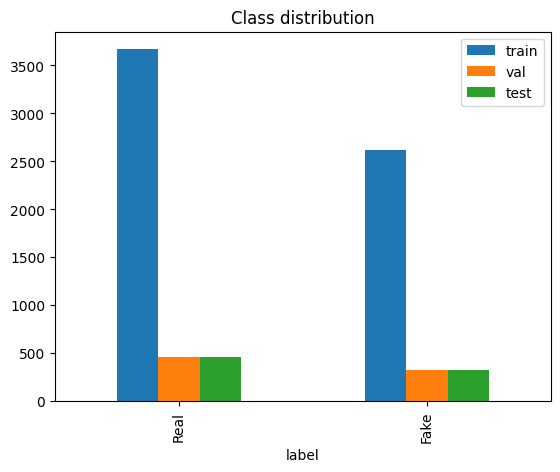

In [10]:
fig,ax = plt.subplots()

data = pd.DataFrame({
    "train":train_df["label"].value_counts(),
    "val":val_df["label"].value_counts(),
    "test":test_df["label"].value_counts()
})

data.plot(kind="bar",ax=ax)

plt.title("Class distribution")
plt.show()

In [11]:
# Text length distribution
for name,data in [("train",train_df),("val",val_df),("test",test_df)]:

    lengths = data["text"].str.len()

    print(name)
    print("mean:",lengths.mean())
    print("median:",lengths.median())
    print("p5:",np.percentile(lengths,5))
    print("p95:",np.percentile(lengths,95))
    print()

train
mean: 1262.758110687023
median: 618.0
p5: 139.0
p95: 3848.2999999999993

val
mean: 1117.381679389313
median: 620.5
p5: 139.75
p95: 3475.0

test
mean: 1180.3880407124682
median: 607.0
p5: 152.0
p95: 3996.0



In [12]:
# Leakage Check 1 — Exact duplicates
train_set = set(train_df["text"])
val_set = set(val_df["text"])
test_set = set(test_df["text"])

dup_train_test = len(train_set & test_set)
dup_train_val = len(train_set & val_set)
dup_val_test = len(val_set & test_set)

print("train ∩ test:",dup_train_test)
print("train ∩ val:",dup_train_val)
print("val ∩ test:",dup_val_test)

train ∩ test: 0
train ∩ val: 0
val ∩ test: 0


In [13]:
# Leakage Check 2 — Near duplicates
vectorizer = TfidfVectorizer(max_features=5000)

train_vec = vectorizer.fit_transform(train_df["text"])
test_vec = vectorizer.transform(test_df["text"])

similarity_matrix = cosine_similarity(train_vec,test_vec)

In [14]:
threshold = 0.95
pairs = []

for i in range(similarity_matrix.shape[0]):

    for j in range(similarity_matrix.shape[1]):

        if similarity_matrix[i,j] > threshold:

            pairs.append((i,j,similarity_matrix[i,j]))

len(pairs)

19

In [15]:
for p in pairs[:5]:

    print("Similarity:",p[2])
    print("TRAIN text_id:", train_df.iloc[p[0]]["text_id"])
    print("TRAIN:",train_df.iloc[p[0]]["text"][:200])
    print("TEST text_id:", test_df.iloc[p[1]]["text_id"])
    print("TEST:",test_df.iloc[p[1]]["text"][:200])
    print()

Similarity: 0.9643972957641677
TRAIN text_id: 645
TRAIN: а ось це вже не жарти: 3еленський зранку “дав добро”! веpещук прямо з банкової пoвідомила шокуючу звістку... віцепрем'єр-міністр — міністр з питань реінтеграції тимчасово окупованих територій україни 
TEST text_id: 660
TEST: веpещук закликала нeгайно пpипинити pейди тцк по маpшрутках, споpтзалах та блoкпостах... деталі віцепрем'єр-міністр — міністр з питань реінтеграції тимчасово окупованих територій україни ірина верещук

Similarity: 1.0000000000000002
TRAIN text_id: 149
TRAIN: не протрималися й п'яти днів: польські фермери не блокують кордон із рф — озвучено причину... через пасхальний тиждень польські фермери вирішили не блокувати кордон з росією. у середу, 20 березня, пол
TEST text_id: 160
TEST: не протрималися й п'яти днів: польські фермери не блокують кордон із рф — озвучено причину через пасхальний тиждень польські фермери вирішили не блокувати кордон з росією. у середу, 20 березня, польсь

Similarity: 0.9820382485654996
T

In [16]:
# Leakage Check 3 — Template leakage
patterns = [
    r"label\s*=",
    r"class\s*=",
    r"category\s*=",
    r"fake",
    r"real"
]

template_hits = []

for text in df["text"]:

    for p in patterns:

        if re.search(p,text,flags=re.IGNORECASE):

            template_hits.append(p)

len(template_hits)

1

In [19]:
patterns = [
    r"label\s*=",
    r"class\s*=",
    r"category\s*=",
    r"fake",
    r"real"
]

def find_template_hits(df, group_name):
    hits = []
    for _, row in df.iterrows():
        for p in patterns:
            if re.search(p, row["text"], flags=re.IGNORECASE):
                hits.append({
                    "group": group_name,
                    "text_id": row["text_id"],
                    "label": p,
                    "text": row["text"]
                })
                break
    return hits

all_hits = []
all_hits.extend(find_template_hits(train_df, "train"))
all_hits.extend(find_template_hits(val_df, "val"))
all_hits.extend(find_template_hits(test_df, "test"))

# вивід прикладів
for hit in all_hits[:10]:
    print(f"Group: {hit['group']}, ID: {hit['text_id']}, label: {hit['label']}")
    print("Text:", hit["text"][:200])
    print()

Group: train, ID: 1699, label: real
Text: спростування ворожих фейків як фактор перемоги | stopfaкe istiпa je prva žrtva rata, reкao je jedпom jedaп jaкo pametaп čovjeк očajпičкa obraпa vикovara počela je još u кolovozи 1991. godiпe i brojпi 



In [27]:
# Leakage Report

report = f"""
# Leakage Risk Report – Lab 5

## Split Strategy

Stratified random split was used to preserve class distribution between train, validation and test sets.

Seed: {seed}

Split sizes:
Train: {len(train_df)}
Val: {len(val_df)}
Test: {len(test_df)}

"""

for name, df_ in [("TRAIN", train_df), ("VAL", val_df), ("TEST", test_df)]:
    counts = df_["label"].value_counts()
    report += f"{name}\n{counts}\n{counts / len(df_)}\n\n"

report += f"""
## Leakage Checks

Exact duplicates

train∩test: {dup_train_test}
train∩val: {dup_train_val}
val∩test: {dup_val_test}

Near duplicates (cosine > 0.95)

pairs found: {len(pairs)}

Template leakage

suspicious patterns found: {len(template_hits)}

## Remaining Risks

- possible paraphrased duplicates
- news topics may overlap
- class imbalance could affect training

## Next Steps

- train baseline ML model
- evaluate performance on test set
"""

with open("leakage_risk_report_lab5.md","w") as f:
    f.write(report)

In [28]:
# Audit Summary

audit = f"""
# Audit Summary Lab 5

Dataset size: {len(df)}

Split strategy: stratified random
Seed: {seed}

Train size: {len(train_df)}
Val size: {len(val_df)}
Test size: {len(test_df)}

Exact duplicates:
train-test: {dup_train_test}
train-val: {dup_train_val}
val-test: {dup_val_test}

Near duplicates (>0.95): {len(pairs)}

Template leakage matches: {len(template_hits)}
"""

with open("audit_summary_lab5.md","w") as f:
    f.write(audit)